# Notebook to demo `clip_line_dist` function.

The function `clip_line_dist` accepts:
- a line segment of the form of an array of x1,y1.x2,y2
- a cell size
- an optional distance (if not specified, distance is 0.0)

It returns an array of items with:
- `q` the q value
- `r` the r value
- `l` the length of the clipped line in the q/r cell.

In [1]:
import geofunctions as S
import pyspark.sql.functions as F
from pyspark.sql import SparkSession

In [2]:
spark.version

'3.5.7'

In [3]:
# Create sample line data
data = [(-1.0, -1.0, 11.0, 11.0)]

df = spark.createDataFrame(data, ["x1", "y1", "x2", "y2"])
df.printSchema()
df.show(truncate=False)

root
 |-- x1: double (nullable = true)
 |-- y1: double (nullable = true)
 |-- x2: double (nullable = true)
 |-- y2: double (nullable = true)

+----+----+----+----+
|x1  |y1  |x2  |y2  |
+----+----+----+----+
|-1.0|-1.0|11.0|11.0|
+----+----+----+----+



In [4]:
(
    df.select(
        F.explode(
            # Convert to array of (q,r,length) tuple.
            S.clip_line_dist(
                F.array("x1", "y1", "x2", "y2"),
                cell = 5.0,
                dist = 0.0,
            )
        )
    )
    .select(
        "col.q",
        "col.r",
        "col.l",
    )
    .show(truncate=False, vertical=False)
)

+---+---+------------------+
|q  |r  |l                 |
+---+---+------------------+
|-1 |-1 |1.4142135623730951|
|0  |0  |7.0710678118654755|
|1  |1  |7.0710678118654755|
|2  |2  |1.4142135623730951|
+---+---+------------------+



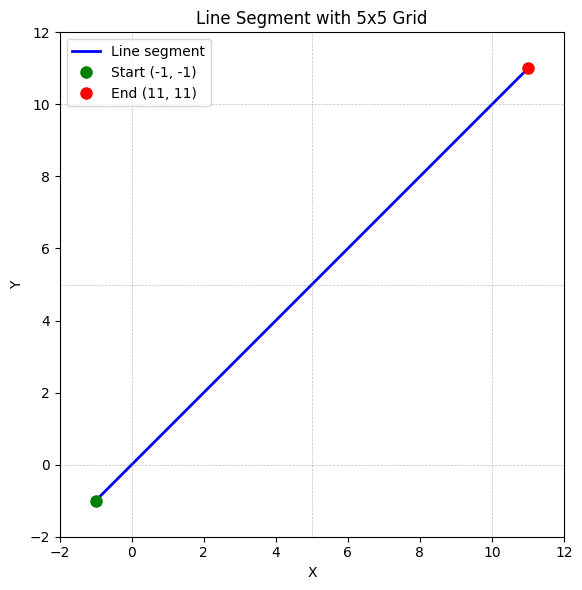

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the line from (-1, -1) to (11, 11)
ax.plot([-1, 11], [-1, 11], 'b-', linewidth=2, label='Line segment')

# Draw 5x5 grid background
for i in np.arange(0, 12, 5):
    ax.axvline(x=i, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)
    ax.axhline(y=i, color='gray', linestyle='--', alpha=0.5, linewidth=0.5)

# Mark the start and end points
ax.plot(-1, -1, 'go', markersize=8, label='Start (-1, -1)')
ax.plot(11, 11, 'ro', markersize=8, label='End (11, 11)')

# Set equal aspect ratio and tight layout
ax.set_aspect('equal')
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Line Segment with 5x5 Grid')
ax.legend()
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()